In [47]:
import pandas as pd 
import numpy as np

In [48]:
data = pd.read_csv("fraud_detection_dataset.csv")

In [49]:
data.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Amount,Merchant_Category,Transaction_Type,Customer_Age,Account_Tenure,Num_Transactions_Last_24H,Location_Match,Fraud
0,TXN0000001,1102,2025-01-14 20:00:00,1928.96,Fuel,POS,31.0,0.0,7.0,1,No
1,TXN0000002,1435,2025-01-08 06:00:00,1651.05,Grocery,Online,44.0,7.0,5.0,1,No
2,TXN0000003,1860,2025-01-28 08:00:00,1324.14,Healthcare,POS,46.0,14.0,5.0,1,No
3,TXN0000004,1270,2025-01-19 08:00:00,1240.01,Healthcare,ATM,56.0,9.0,7.0,1,No
4,TXN0000005,1106,2025-01-06 05:00:00,1122.22,Grocery,Online,56.0,2.0,6.0,1,No


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             5000 non-null   object 
 1   Customer_ID                5000 non-null   int64  
 2   Transaction_DateTime       5000 non-null   object 
 3   Transaction_Amount         4750 non-null   float64
 4   Merchant_Category          4850 non-null   object 
 5   Transaction_Type           5000 non-null   object 
 6   Customer_Age               4800 non-null   float64
 7   Account_Tenure             4700 non-null   float64
 8   Num_Transactions_Last_24H  4750 non-null   float64
 9   Location_Match             5000 non-null   int64  
 10  Fraud                      5000 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 429.8+ KB


In [51]:
data.describe()

,Customer_ID,Transaction_Amount,Customer_Age,Account_Tenure,Num_Transactions_Last_24H,Location_Match
count,5000.000000,4750.000000,4800.000000,4700.000000,4750.000000,5000.000000
mean,1505.701200,1193.692676,43.413542,6.994681,5.106947,0.899400
std,290.836902,502.846003,14.909871,4.330781,2.567500,0.300828
min,1000.000000,50.000000,18.000000,0.000000,1.000000,0.000000
25%,1253.000000,842.000000,31.000000,3.000000,3.000000,1.000000
50%,1510.000000,1197.495000,43.000000,7.000000,5.000000,1.000000
75%,1761.000000,1534.707500,56.000000,11.000000,7.000000,1.000000
max,1999.000000,2977.810000,69.000000,14.000000,9.000000,1.000000


In [52]:
data.isnull().sum()

Transaction_ID                 0
Customer_ID                    0
Transaction_DateTime           0
Transaction_Amount           250
Merchant_Category            150
Transaction_Type               0
Customer_Age                 200
Account_Tenure               300
Num_Transactions_Last_24H    250
Location_Match                 0
Fraud                          0
dtype: int64

In [53]:
data['Merchant_Category']= data['Merchant_Category'].fillna("Unknown")

In [54]:
data = data.drop(['Transaction_ID', 'Customer_ID'], axis=1)

In [55]:
data['Transaction_DateTime'] = pd.to_datetime(data['Transaction_DateTime'])

data['Hour'] = data['Transaction_DateTime'].dt.hour
data['Day'] = data['Transaction_DateTime'].dt.day
data['Month'] = data['Transaction_DateTime'].dt.month

data = data.drop('Transaction_DateTime', axis=1)

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Merchant_Category'] = le.fit_transform(data['Merchant_Category'])
data['Transaction_Type'] = le.fit_transform(data['Transaction_Type'])
data['Location_Match'] = le.fit_transform(data['Location_Match'])
data['Fraud'] = le.fit_transform(data['Fraud'])

In [57]:
X = data.drop('Fraud', axis=1)
y = data['Fraud']

In [58]:
data['Fraud'].value_counts()

Fraud
0    4834
1     166
Name: count, dtype: int64

In [59]:
import matplotlib.pyplot as plt 
import seaborn as sns 

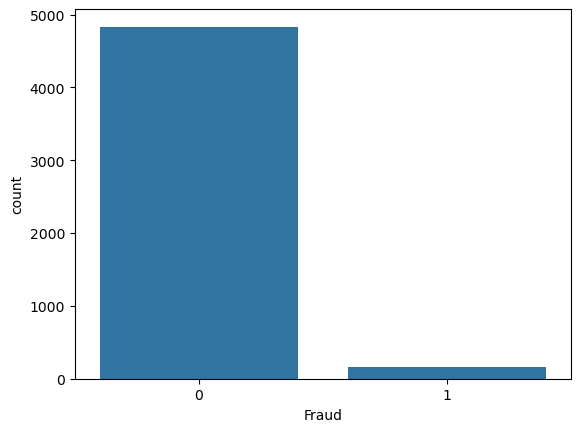

In [60]:
sns.countplot(x= 'Fraud', data=data)
plt.show()

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [62]:
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object', 'category']).columns

X_processed = X.copy()

scaler = StandardScaler()
X_processed[numeric_columns] = scaler.fit_transform(X[numeric_columns])


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

In [64]:
from sklearn.ensemble import IsolationForest 

In [65]:
iso = IsolationForest(contamination=0.02)

iso.fit(X_train)

preds = iso.predict(X_test)

In [66]:
-1 == "Fraud"
1 == "normal"

False

In [67]:
preds = np.where(preds == -1, 1, 0)

In [68]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [69]:
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[951  14]
 [ 35   0]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       965
           1       0.00      0.00      0.00        35

    accuracy                           0.95      1000
   macro avg       0.48      0.49      0.49      1000
weighted avg       0.93      0.95      0.94      1000



In [70]:
roc_auc_score(y_test, preds)

np.float64(0.4927461139896373)

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

iso_accuracy = accuracy_score(y_test, preds)
iso_precision = precision_score(y_test, preds)
iso_recall = recall_score(y_test, preds)
iso_f1 = f1_score(y_test, preds)

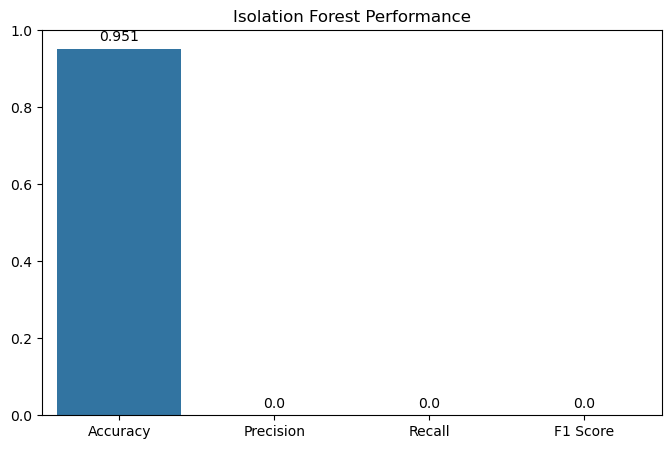

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy','Precision','Recall','F1 Score']
values = [iso_accuracy, iso_precision, iso_recall, iso_f1]

plt.figure(figsize=(8,5))
sns.barplot(x=metrics, y=values)

plt.title("Isolation Forest Performance")
plt.ylim(0,1)

for i,v in enumerate(values):
    plt.text(i, v+0.02, round(v,3), ha='center')

plt.show()

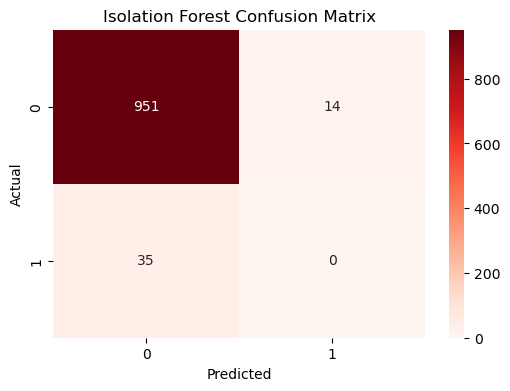

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")

plt.show()

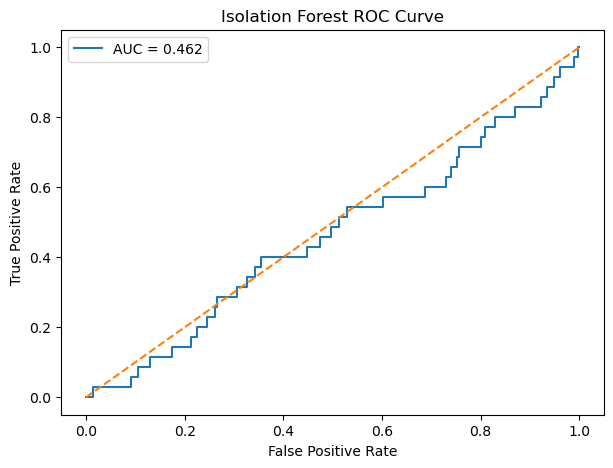

In [74]:
from sklearn.metrics import roc_curve, roc_auc_score

iso_scores = -iso.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, iso_scores)

roc_auc = roc_auc_score(y_test, iso_scores)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Isolation Forest ROC Curve")
plt.legend()

plt.show()

In [75]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.01, random_state=42)
iso_model.fit(X)

IsolationForest(contamination=0.01, random_state=42)

In [76]:
import joblib

joblib.dump(iso_model, "isolation_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']